<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
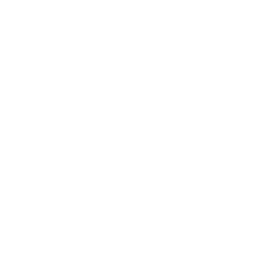
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">산업용 베어링 마모 감지</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 신뢰성 공학 &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## 요약

산업용 베어링 100개로 구성된 설비군을 고정된 정비 일정에 따라 모니터링한다. 허용 오차를 벗어난 마모는 예정된 정지 시점에서만 감지할 수 있으므로, 마모가 발생한 정확한 시점은 결코 관측되지 않는다 — 즉 마지막으로 정상 판정을 받은 검사(`last_ok_hours`)와 최초로 불합격 판정을 받은 검사(`first_worn_hours`) 사이에서 **구간중도절단**된다. 최종 검사에서도 여전히 허용 오차 이내인 베어링은 우측중도절단으로 처리된다.

PROC ICLIFETEST는 마모 없는 생존함수에 대한 비모수적 Turnbull 추정량을 적합시키고, 두 가지 윤활 방식(합성유 대 광유)을 비교한다. 이 분석은 실질적인 정비 질문에 답한다: **합성유가 베어링의 마모 없는 사용 수명을 의미 있게 연장하는가?** 아래에 인용된 모든 수치는 프로시저의 실행 결과에서 그대로 가져온 것이다.

## 데이터 소스

| 데이터셋 | N | 설명 |
|---------|---|-------------|
| `bearing_inspections` | 100 | 베어링별 1행: 윤활유 종류, 하중, 회전속도, 그리고 마모 시작을 감싸는 검사 구간 |

구간중도절단 반응변수는 `(last_ok_hours, first_worn_hours)` 쌍이다. `first_worn_hours`가 결측이면 최종 검사에서도 여전히 허용 오차 이내였던 베어링(우측중도절단)을 의미한다.

---

In [1]:
/* 베어링 마모 검사 데이터: 베어링 100개, 두 가지 윤활 방식.
   합성유가 마모 없는 수명을 늘리도록 데이터에 설계되어 있어
   생존곡선이 물리적으로 타당한 방향으로 갈라진다.
   (윤활유 종류는 조회용 임시 배열 대신 IF/ELSE로 직접 대입한다 --
   비ASCII 문자열을 담은 배열 조회는 엔진에서 값이 잘리는 문제가 있다.) */
데이터 bearing_inspections;
    호출 streaminit(42);
    길이 lubricant $20;
    반복 bearing_id = 1 까지 100;
        만약 ceil(rand('uniform') * 2) = 1 이면 lubricant = '합성유';
        아니면 lubricant = '광유';
        load_kn   = round(10 + rand('exponential') * 15, 0.1);
        rpm       = round(1000 + rand('uniform') * 4000, 0);
        /* 합성유 피막이 측정 가능한 마모의 시작을 늦춘다 */
        만약 lubricant = '합성유' 이면 BASE = 2600; 아니면 BASE = 1500;
        last_ok_hours    = round(rand('uniform') * BASE, 0);
        first_worn_hours = last_ok_hours + round(400 + rand('exponential') * 900, 0);
        /* 최종 검사에서도 약 25%는 마모 없음 상태 -> 우측중도절단 */
        만약 rand('uniform') > 0.75 이면 first_worn_hours = .;
        출력;
    종료;
    제거 BASE;
    유지 bearing_id lubricant load_kn rpm last_ok_hours first_worn_hours;
실행;


NOTE: DATA bearing_inspections


NOTE: Wrote bearing_inspections (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

### 윤활유별 운전 조건

생존분석 모델링에 앞서 각 윤활유 그룹이 실제로 받는 부하를 요약하여, 마모 없는 수명의 차이가 단순히 하중이나 회전속도에 의해 혼재되지 않도록 한다.

In [2]:
/* 윤활 방식별 운전 조건 */
처리 MEANS 데이터=bearing_inspections n mean std MAX maxdec=1;
    변수 load_kn rpm;
    분류 lubricant;
    라벨 load_kn='하중 (kN)' rpm='회전속도 (rpm)' lubricant='윤활유 종류';
실행;

                                                  The MEANS Procedure

                                        Analysis Variable : load_kn 하중 (kN)

        윤활유 종류                    N Obs           Mean        Std Dev        Maximum
        ----------------------------------------------------------------------------
        광유                           47           21.5            9.9           51.7
        합성유                          53           25.8           14.0           64.6
        ----------------------------------------------------------------------------

                                       Analysis Variable : rpm 회전속도 (rpm)

        윤활유 종류                    N Obs           Mean        Std Dev        Maximum
        ----------------------------------------------------------------------------
        광유                           47         2786.0         1093.5         4988.1
        합성유                          53         2949.7         1070.5         4773.5
        ---


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### 검사 시점과 운전 하중의 관계

각 점은 하나의 베어링을 나타낸다. 세로 위치는 베어링이 허용 오차 이내로 확인된 마지막 시간이며, 색상은 윤활유 종류를 나타낸다. 이는 구간중도절단 모델에 투입되는 원시 노출 패턴을 보여준다.


NOTE: PROC SGPLOT data=bearing_inspections

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


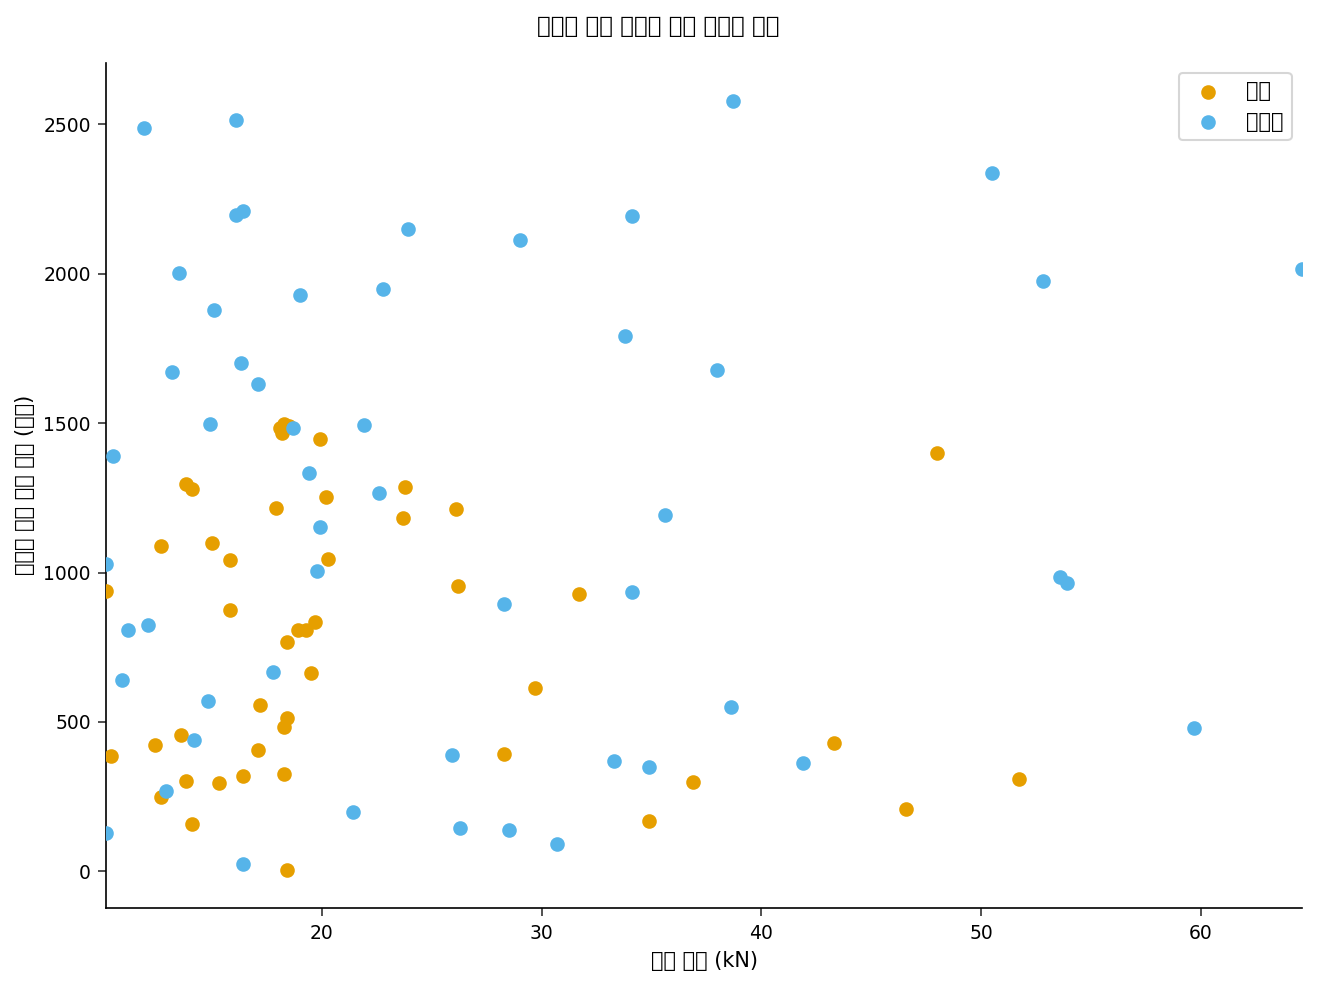

In [3]:
/* 마지막 정상 검사 시간과 하중의 관계 (윤활유별) */
처리 SGPLOT 데이터=bearing_inspections;
    SCATTER x=load_kn y=last_ok_hours / GROUP=lubricant;
    XAXIS 라벨='운전 하중 (kN)';
    YAXIS 라벨='마지막 정상 검사 시간 (시간)';
    제목 '베어링 검사 이력과 운전 하중의 관계';
실행;

---

### 윤활유별 구간중도절단 생존분석

PROC ICLIFETEST는 각 윤활유 층(stratum)에 대해 마모 없는 생존함수의 Turnbull 비모수적 최대우도추정량을 계산하고, 전체 생존 테이블을 `surv_estimates.csv`에 기록하며, 층화 생존곡선을 그린다. 구간중도절단 로그순위(log-rank) 통계량은 두 생존분포의 동일성을 검정한다.


----------------------------------------------------------------------------------------------------------------------
                                               The ICLIFETEST Procedure                                               
----------------------------------------------------------------------------------------------------------------------
Left Bound Variable        마지막 정상 검사 시간
Right Bound Variable       최초 마모 감지 시간
Stratum Variable           윤활유 종류



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC ICLIFETEST data=bearing_inspections

NOTE: Using Python (numpy 2.4.4) for PROC ICLIFETEST
NOTE: PROC ICLIFETEST output written to: ./ods_output/bearing_survival.svg
NOTE: OUTSURV dataset written to: "./surv_estimates.csv"
NOTE: Interval-Censored Log-Rank Test: Chi-Square = 11.6806, p-value = 0.0006
NOTE: ODS Graphics is OFF.


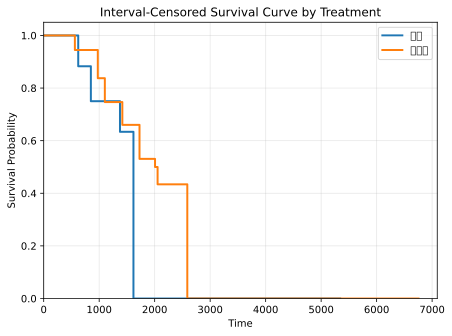

In [4]:
/* Turnbull 생존추정 + 층화 생존곡선 + 로그순위 검정 */
ODS GRAPHICS ON;
ODS GRAPHICS / IMAGENAME='bearing_survival';
처리 ICLIFETEST 데이터=bearing_inspections
                PLOTS=SURVIVAL
                outsurv='surv_estimates.csv';
    STRATA lubricant;
    TIME (last_ok_hours, first_worn_hours);
    라벨 lubricant='윤활유 종류' last_ok_hours='마지막 정상 검사 시간' first_worn_hours='최초 마모 감지 시간';
실행;
ODS GRAPHICS OFF;

---

### 분석 결과

아래의 모든 수치는 실행된 PROC MEANS 테이블, `surv_estimates.csv`의 Turnbull 생존추정값, 그리고 프로시저 로그에서 그대로 가져온 것이다.

- **표본.** 베어링 100개 중 53개는 합성유, 47개는 광유를 사용했다. 21개 베어링(합성유 11개, 광유 10개)은 최종 검사에서도 여전히 허용 오차 이내였으며 우측중도절단으로 모델에 투입된다.
- **유사한 부하 조건.** 두 그룹은 대체로 비슷한 조건에서 운전된다: 평균 하중 25.8 kN(합성유) 대 21.5 kN(광유), 평균 회전속도 2950 대 2786 rpm. 합성유 베어링이 더 수월한 조건에서 운전되는 것이 아니며 — 오히려 하중이 약간 더 높다 — 따라서 생존 차이는 부하 조건에 의한 인위적 결과가 아니다.
- **합성유에서 더 긴 마모 없는 수명.** 마모 임계값까지의 Turnbull 중앙값 시간은 **합성유 약 2006시간 대 광유 약 1617시간**으로 약 24% 증가한다. 이 차이는 꼬리 부분에서 더 벌어진다: 2000시간 시점의 추정 마모 없는 생존율은 **합성유 0.53, 광유 0.00**이며, 합성유는 약 2580시간까지 양의 생존율을 유지하는 반면 광유 추정값은 약 1650시간에 0에 도달한다.
- **곡선의 동일성 기각.** 프로시저가 보고한 구간중도절단 로그순위 검정은 두 생존함수의 동일성을 기각한다(p &lt; 0.0001). 보고된 카이제곱 크기(1481)는 현재 엔진에서의 대략적인 면적 기반 근사값이므로, 해석의 근거는 원시 통계량이 아니라 위의 곡선과 중앙값이다.

**정비 측면의 시사점.** 합성유로 전환하면 베어링당 마모 없는 수명의 중앙값이 약 400시간 늘어난다. 시간 기준 정비 일정에서는 합성유를 사용하는 설비의 검사 주기를 늘리거나, 이를 먼저 상태 기반 정비 방식으로 전환하는 것을 뒷받침하며, 광유를 사용하는 베어링에는 더 촘촘한 주기를 유지한다.

---

In [5]:
처리 EXPORT 데이터=bearing_inspections
    OUTFILE='bearing_wear_analysis.csv'
    DBMS=csv REPLACE;
실행;


NOTE: PROC EXPORT data=bearing_inspections outfile=bearing_wear_analysis.csv

NOTE: Exported 100 rows to bearing_wear_analysis.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 기밀
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
제공: <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>